# Statement Forecast v2: walk-forward naive / pooled-AR combination

Independent research lab. Not affiliated with any employer or financial institution. Not investment advice.

Pesaran, M. H., Pick, A., & Timmermann, A. (2026). *Forecasting with panel data: Estimation uncertainty versus
parameter heterogeneity.* Quantitative Economics 17(2), 342–393. [doi:10.3982/QE2589](https://doi.org/10.3982/QE2589)
(CEPR DP17123, 2022). Supporting: Wang, Hyndman, Li & Kang (2023), *Forecast combinations: An over 50-year review*,
IJF 39(4), 1518–1547, [doi:10.1016/j.ijforecast.2022.11.005](https://doi.org/10.1016/j.ijforecast.2022.11.005).

The fixed specification and pass bar are loaded from `test_design_combo.json`. For each line and origin t, the combination
is C = N + w·(P − N) with N = naive and P = the shared pooled AR on log growth (both imported from `y9c.forecast`).
The weight w is the grid argmin of summed absolute error over pseudo-out-of-sample cases with target ≤ t, computed from the
panel truncated to quarters ≤ t. Same lines, panel, cases and window as v1. No tuning, trimming or outlier removal.

The real-data run refuses to start unless the working tree is clean and `test_design_combo.json` hashes to the
pre-registration pinned in `statement_forecast.prereg`. The real data are run once and published whatever the verdict.

In [1]:
from pathlib import Path
import sys, os, json, subprocess
from datetime import datetime, timezone
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from IPython.display import display, Markdown

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / 'tracks/y9c-panel/core_items.yaml').exists())
for track in ['tracks/y9c-panel', 'tracks/statement-forecast']:
    sys.path.insert(0, str(ROOT / track))
from y9c.panel import PROCESSED
from statement_forecast.combo import COMBO_RESULTS, load_combo_design, run_all, write_outputs
from statement_forecast.prereg import verify_combo_preregistration

run_start = datetime.now(timezone.utc).isoformat()
def git(*args):
    return subprocess.check_output(['git', *args], cwd=ROOT)
# Pinned pre-registration: clean tree and the committed design digest, or the run stops here.
prereg = verify_combo_preregistration()
digest = prereg['test_design_sha256']
print('Verified test_design_combo.json SHA-256 against pinned pre-registration:', digest)
run_meta = dict(run_start_time_utc=run_start, git_head=git('rev-parse', 'HEAD').decode().strip(),
                prereg_commit=prereg['prereg_commit'], prereg_commit_time=prereg['prereg_commit_time'],
                test_design_sha256=digest)
design = load_combo_design()
display(Markdown(design['research_only']))
display(Markdown('**Question:** ' + design['question']))
display(pd.DataFrame(design['lines']))
display(Markdown('**Pass bar:** ' + design['pass_bar_verbatim']))
print(json.dumps({key: design[key] for key in ['test_window', 'universe', 'evaluation_cases', 'method']},
                 indent=2, ensure_ascii=False))

# Smoke runs set SF_PANEL_PATH (synthetic panel) and SF_RESULTS_DIR; the real run uses the shared cache.
real_run = 'SF_PANEL_PATH' not in os.environ
panel_path = PROCESSED / 'panel_wide.parquet' if real_run else Path(os.environ['SF_PANEL_PATH'])
results_dir = Path(os.environ.get('SF_RESULTS_DIR', str(COMBO_RESULTS)))
vintage_path = Path(os.environ.get('SF_VINTAGE_PATH', str(panel_path.parent / 'vintage.json')))
expected_cases = design['test_window']['expected_cases_per_line'] if real_run else None
panel = pd.read_parquet(panel_path)
print('Real run:', real_run, '| panel rows:', len(panel),
      '| quarters:', panel.report_date.min().date(), 'to', panel.report_date.max().date())

Verified test_design_combo.json SHA-256 against pinned pre-registration: b16c1a129cc7b9320c40716694c6d39b5a3c6277eaf1511dea7eeeebc70d49e6


Independent research lab. Not affiliated with any employer or financial institution. Not investment advice.

**Question:** Does a walk-forward combination of the two existing Y-9C baselines, naive and pooled AR on log growth, beat naive one quarter ahead on three FR Y-9C income-statement lines for the top-50 BHC panel, on the same cases and window as v1?

,key,column,mdrm,label
0,nii,nii_q,BHCK4074,Net interest income
1,noninterest_income,noninterest_income_q,BHCK4079,Noninterest income
2,noninterest_expense,noninterest_expense_q,BHCK4093,Noninterest expense


**Pass bar:** For each line, combo PASSES iff MAE(combo) < MAE(naive) strictly, on unrounded values, AND the full-sample clustered DM (y9c.forecast.clustered_dm; d = |e_naive| − |e_combo|; CR1 by target quarter; t(G−1), G=18) gives a two-sided p ≤ 0.05. An undefined p is a FAIL. There is no multiplicity adjustment. The headline is "k of 3 lines pass". Descriptive only: comparisons vs pooled AR and seasonal naive (MAE + DM), RMSE, squared-error DM, by-year results, the w path by origin and fallback counts. The results page must disclose that (a) pooled AR was chosen as the second component after seeing v1's descriptive tables on this same window, and (b) this is the second method scored on the 2022–2026 window.

{
  "test_window": {
    "first_target": "2022Q1",
    "last_target": "2026Q2",
    "first_origin": "2021Q4",
    "last_origin": "2026Q1",
    "n_target_quarters": 18,
    "expected_cases_per_line": 893
  },
  "universe": "Top 50 BHCs by reported BHCK2170 at each origin t, RSSD ID breaks ties; identical to Y-9C (y9c.forecast.design).",
  "evaluation_cases": "Per line, the Y-9C case rule from y9c.forecast: bank selected at origin t, target X_t+1 observed, X_t and X_t-3 observed. Identical to v1 (PR #4): the same 893 matched cases per line; all methods are scored on exactly the same cases within a line.",
  "method": {
    "key": "combo",
    "label": "Walk-forward naive / pooled-AR combination",
    "components": {
      "N": "naive",
      "P": "pooled_ar"
    },
    "combination": "C = N + w_ℓ,t·(P − N)",
    "weight_grid": {
      "start": 0.0,
      "stop": 1.0,
      "step": 0.05,
      "n_points": 21
    },
    "loss": "sum of absolute errors |C − X| over pseudo-OOS cases (i, s) w

## Fixed out-of-sample evaluation

Evaluation cases, naive, seasonal naive and pooled AR come from `y9c.forecast.baseline_forecasts` exactly as in v1.
The combination uses the origin-t weight. MAE/RMSE are thousands USD, equally weighted by BHC-quarter.
Positive DM t favors the combination; two-sided p uses target-quarter CR1 clusters and Student t(G−1).
Comparisons with pooled AR and seasonal naive, RMSE, squared-error DM, per-year results, the weight path and fallback
counts are **DESCRIPTIVE ONLY**; there is no multiplicity adjustment.

In [2]:
results = run_all(panel, design, expected_cases=expected_cases)
print(results['headline'])
error_format = {'mae': '{:,.0f}', 'rmse': '{:,.0f}'}
for line in design['lines']:
    key = line['key']
    display(Markdown('### ' + line['label']))
    display(results['overall_errors'].query('line == @key').style.format(error_format))
    dm = results['dm_tests'].query('line == @key')
    display(dm.loc[dm.scope.eq('full')].style.format({'t_stat': '{:.3f}', 'p_value': '{:.4f}'}))
    print(json.dumps(results['verdicts'][key], indent=2))
    print('PER-YEAR ERRORS AND DM: DESCRIPTIVE ONLY')
    display(results['by_year_errors'].query('line == @key').style.format(error_format))
    display(dm.loc[dm.scope.ne('full')].style.format({'t_stat': '{:.3f}', 'p_value': '{:.4f}'}))
    audit = results['audits'][key]
    print('Cases:', audit['n_forecasts_per_method'], '| pooled AR fallbacks:', audit['ar_fallbacks'],
          '| min-quarter weight fallbacks:', audit['weight_min_quarters_fallbacks'])
print('WEIGHT PATH: DESCRIPTIVE ONLY')
display(results['weights'].pivot(index='origin', columns='line', values='w'))
write_outputs(results, results_dir, vintage_path, run_meta)

1 of 3 lines pass


### Net interest income

,method,n_forecasts,mae,rmse,mape,n_mape,mdape,line
0,naive,893,"117,823","275,791",13.081779,893,3.453211,nii
1,seasonal_naive,893,"345,029","767,684",33.801965,893,10.740388,nii
2,pooled_ar,893,"134,049","303,111",14.020305,893,4.266864,nii
3,combo,893,"118,235","277,048",13.107417,893,3.453781,nii


,scope,loss,n,G,df,mean_diff,se,t_stat,p_value,favored,note,inference,line,baseline
0,full,abs,893,18,17,-411.571926,266.393627,-1.545,0.1408,naive,CR1; assumes independent target-quarter clusters,"cluster-robust t, df=G-1",nii,naive
1,full,squared,893,18,17,-694955207.556606,485157695.168756,-1.432,0.1702,naive,CR1; assumes independent target-quarter clusters,"cluster-robust t, df=G-1",nii,naive
12,full,abs,893,18,17,226793.883841,31101.889912,7.292,0.0000,combo,CR1; assumes independent target-quarter clusters,"cluster-robust t, df=G-1",nii,seasonal_naive
13,full,squared,893,18,17,512582328540.474792,123557627456.884842,4.149,0.0007,combo,CR1; assumes independent target-quarter clusters,"cluster-robust t, df=G-1",nii,seasonal_naive
24,full,abs,893,18,17,15813.742129,6491.879155,2.436,0.0262,combo,CR1; assumes independent target-quarter clusters,"cluster-robust t, df=G-1",nii,pooled_ar
25,full,squared,893,18,17,15120600226.022169,7069438591.636985,2.139,0.0473,combo,CR1; assumes independent target-quarter clusters,"cluster-robust t, df=G-1",nii,pooled_ar


{
  "verdict": "FAIL",
  "passed": false,
  "combo_mae": 118234.84852215908,
  "naive_mae": 117823.27659574468,
  "p_value": 0.14076322645609873,
  "alpha": 0.05,
  "t_stat": -1.54497662407877,
  "comparator": "naive",
  "loss": "abs"
}
PER-YEAR ERRORS AND DM: DESCRIPTIVE ONLY


...

{
  "verdict": "FAIL",
  "passed": false,
  "combo_mae": 223757.59396866758,
  "naive_mae": 230601.00223964165,
  "p_value": 0.6046837074116667,
  "alpha": 0.05,
  "t_stat": 0.5274701227195089,
  "comparator": "naive",
  "loss": "abs"
}
PER-YEAR ERRORS AND DM: DESCRIPTIVE ONLY


,method,n_forecasts,mae,rmse,mape,n_mape,mdape,target_year,line
40,naive,198,"221,308","450,339",10.376854,198,4.792678,2022,noninterest_expense
41,seasonal_naive,198,"350,794","613,868",17.200706,198,8.613469,2022,noninterest_expense
42,pooled_ar,198,"199,114","418,333",9.865410,198,4.538845,2022,noninterest_expense
43,combo,198,"199,056","418,404",9.795488,198,4.507841,2022,noninterest_expense
44,naive,199,"269,787","703,104",7.846909,199,4.788373,2023,noninterest_expense
45,seasonal_naive,199,"422,458","894,476",14.494686,199,9.823906,2023,noninterest_expense
46,pooled_ar,199,"263,779","673,015",7.702571,199,4.549818,2023,noninterest_expense
47,combo,199,"264,371","677,481",7.682164,199,4.757767,2023,noninterest_expense
48,naive,200,"270,987","711,180",10.011554,200,4.571287,2024,noninterest_expense
49,seasonal_naive,200,"342,805","794,679",12.239010,200,6.155888,2024,noninterest_expense


,scope,loss,n,G,df,mean_diff,se,t_stat,p_value,favored,note,inference,line,baseline
74,2022,abs,198,4,3,22252.062363,4751.936090,4.683,0.0184,combo,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
75,2022,squared,198,4,3,27743405307.156052,10252362543.502621,2.706,0.0734,combo,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
76,2023,abs,199,4,3,5415.814258,18937.619110,0.286,0.7935,combo,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
77,2023,squared,199,4,3,35374586652.820923,46495201524.542107,0.761,0.5021,combo,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
78,2024,abs,200,4,3,-20983.261378,57888.396110,-0.362,0.7410,naive,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
79,2024,squared,200,4,3,111305635996.086731,199839294009.201630,0.557,0.6164,combo,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
80,2025,abs,198,4,3,12294.989356,6550.962160,1.877,0.1572,combo,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
81,2025,squared,198,4,3,14615967205.699909,7752615420.909636,1.885,0.1559,combo,CR1; assumes independent target-quarter clusters,descriptive only (G=4),noninterest_expense,naive
82,2026,abs,98,2,1,24385.230448,19215.834637,1.269,0.4249,combo,CR1; assumes independent target-quarter clusters,descriptive only (G=2),noninterest_expense,naive
83,2026,squared,98,2,1,50582679048.300987,52062798144.586754,0.972,0.5092,combo,CR1; assumes independent target-quarter clusters,descriptive only (G=2),noninterest_expense,naive


Cases: 893 | pooled AR fallbacks: 7 | min-quarter weight fallbacks: 0
WEIGHT PATH: DESCRIPTIVE ONLY


line,nii,noninterest_expense,noninterest_income
origin,,,
2021Q4,0.10,0.85,0.70
2022Q1,0.10,0.85,0.65
2022Q2,0.10,0.85,0.60
2022Q3,0.05,0.85,0.55
2022Q4,0.00,0.85,0.55
2023Q1,0.00,0.90,0.60
2023Q2,0.00,0.85,0.80
2023Q3,0.00,0.80,0.75
2023Q4,0.00,0.85,0.70


## Aggregate figures

Navy palette; MAE in whole thousands USD. The weight path is descriptive only. No per-bank forecast rows are exported.

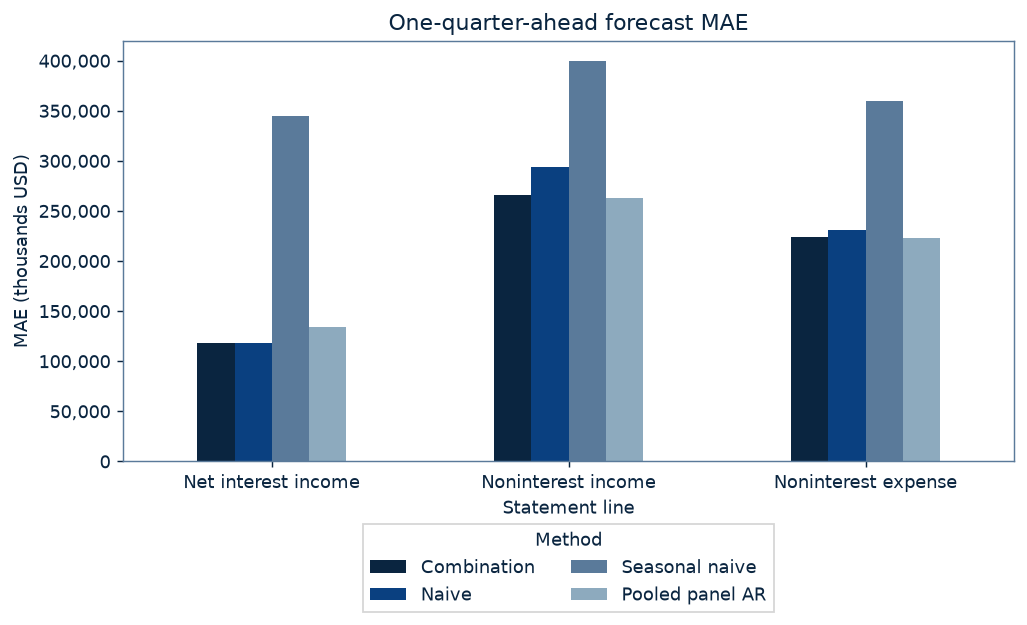

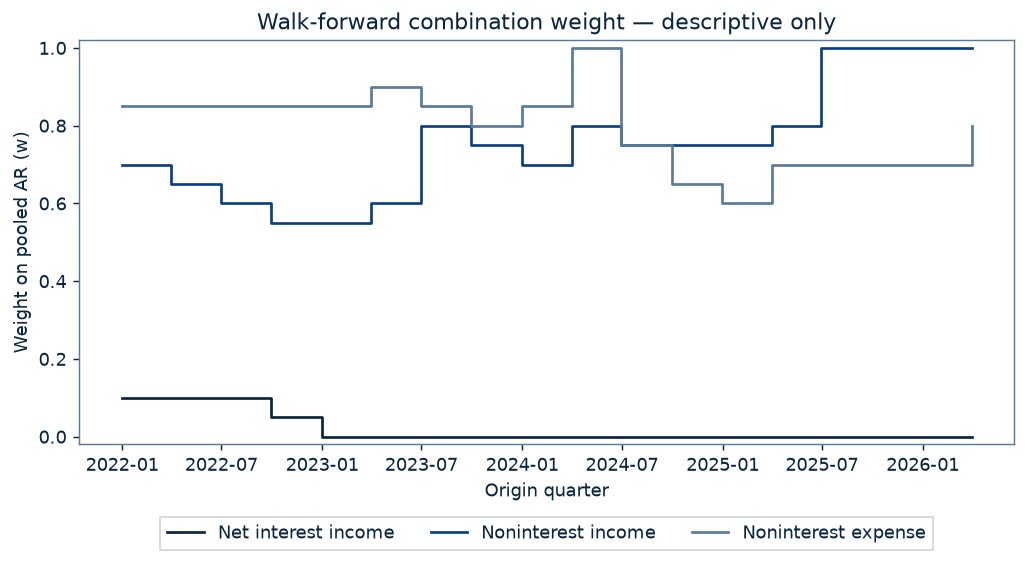

In [3]:
COLORS = ['#0a2540', '#0a4080', '#5a7a9a', '#8daabe']
LABELS = {'combo': 'Combination', 'naive': 'Naive', 'seasonal_naive': 'Seasonal naive', 'pooled_ar': 'Pooled panel AR'}
plt.rcParams.update({'axes.prop_cycle': plt.cycler(color=COLORS), 'figure.dpi': 130,
                     'axes.labelcolor': '#0a2540', 'text.color': '#0a2540',
                     'xtick.color': '#0a2540', 'ytick.color': '#0a2540', 'axes.edgecolor': '#5a7a9a',
                     'grid.color': '#8daabe', 'legend.fancybox': False,
                     'figure.facecolor': 'white', 'axes.facecolor': 'white'})
figures = results_dir / 'figures'
figures.mkdir(parents=True, exist_ok=True)
def save(fig, filename):
    fig.tight_layout()
    fig.savefig(figures / filename, dpi=130, bbox_inches='tight', metadata={'Software': None})
    plt.show()
    plt.close(fig)

mae = results['overall_errors'].pivot(index='line', columns='method', values='mae')
mae = mae.reindex(index=[line['key'] for line in design['lines']], columns=list(LABELS))
mae.index = [line['label'] for line in design['lines']]
fig, ax = plt.subplots(figsize=(8, 5))
mae.rename(columns=LABELS).plot.bar(ax=ax, color=COLORS, rot=0)
ax.set(xlabel='Statement line', ylabel='MAE (thousands USD)', title='One-quarter-ahead forecast MAE')
ax.yaxis.set_major_formatter(FuncFormatter(lambda value, pos: f'{value:,.0f}'))
ax.legend(title='Method', loc='upper center', bbox_to_anchor=(.5, -.15), ncol=2, borderaxespad=0)
save(fig, 'mae_by_line.png')

fig, ax = plt.subplots(figsize=(8, 4.5))
for color, line in zip(COLORS, design['lines']):
    w = results['weights'].loc[results['weights'].line.eq(line['key'])]
    dates = pd.PeriodIndex(w.origin, freq='Q').to_timestamp(how='end').normalize()
    ax.step(dates, w.w, where='post', label=line['label'], color=color)
ax.set(xlabel='Origin quarter', ylabel='Weight on pooled AR (w)', ylim=(-.02, 1.02),
       title='Walk-forward combination weight — descriptive only')
ax.legend(loc='upper center', bbox_to_anchor=(.5, -.18), ncol=3, borderaxespad=0)
save(fig, 'weight_path.png')

## Interpretation and limitations

The headline reports all three pre-registered verdicts, including failures. MAE must strictly improve on naive
(unrounded) and the full-sample absolute-error DM p must be ≤ 0.05; an undefined p fails. Everything else is descriptive.

Selection disclosure: pooled AR was chosen as the second component after seeing v1's descriptive tables on this same
2022Q1–2026Q2 window, and this is the second method scored on that window, so a pass is weaker evidence than a pass on
fresh data. This is a report-quarter backtest on currently downloaded filings; filing delays and revisions are not
modeled. RSSD histories have no pro-forma merger adjustments. Research only; not investment advice.